In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [94]:
df = pd.read_csv("housing.csv")

In [95]:
df.columns.to_list()

['longitude',
 'latitude',
 'housing_median_age',
 'total_rooms',
 'total_bedrooms',
 'population',
 'households',
 'median_income',
 'median_house_value',
 'ocean_proximity']

In [96]:
df.shape

(20640, 10)

In [97]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [98]:
data_descibtion = df.describe()

In [99]:
data_descibtion

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [100]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [101]:
df.tail()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND
20639,-121.24,39.37,16.0,2785.0,616.0,1387.0,530.0,2.3886,89400.0,INLAND


In [102]:
df.sample()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
9885,-121.77,36.71,18.0,6601.0,1395.0,3562.0,1299.0,3.512,174800.0,<1H OCEAN


| Column | Description |
|------|------|
| longitude | The geographical longitude of the house location (east–west position on the map). |
| latitude | The geographical latitude of the house location (north–south position on the map). |
| housing_median_age | The median age of houses in a given block/group of houses (in years). |
| total_rooms | The total number of rooms in all houses within the block. |
| total_bedrooms | The total number of bedrooms in all houses within the block. |
| population | The total number of people living in the block. |
| households | The total number of households (families or housing units) in the block. |
| median_income | The median income of households in the block (usually measured in tens of thousands of dollars). |
| median_house_value | The median house price/value in the block (this is usually the target variable in prediction tasks). |
| ocean_proximity | A categorical feature describing how close the location is to the ocean (e.g., NEAR BAY, INLAND, NEAR OCEAN, ISLAND). |

In [103]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [104]:
print(df['total_bedrooms'].mean())
print(df['total_bedrooms'].median())

537.8705525375618
435.0


In [105]:
df['total_bedrooms'].value_counts()

total_bedrooms
280.0     55
331.0     51
345.0     50
393.0     49
343.0     49
          ..
2309.0     1
3521.0     1
3008.0     1
1857.0     1
1052.0     1
Name: count, Length: 1923, dtype: int64

In [106]:
print(df['total_bedrooms'].corr(df['total_rooms']))

0.9303795046865075


In [107]:
df['rooms_bin'] = pd.qcut(df['total_rooms'], q=10)
median_bedrooms = df.groupby('rooms_bin')['total_bedrooms'].transform('median')

In [108]:
df[df['total_bedrooms'].isnull()]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,rooms_bin
290,-122.16,37.77,47.0,1256.0,NaN,570.0,218.0,4.3750,161900.0,NEAR BAY,"(941.0, 1298.0]"
341,-122.17,37.75,38.0,992.0,NaN,732.0,259.0,1.6196,85100.0,NEAR BAY,"(941.0, 1298.0]"
538,-122.28,37.78,29.0,5154.0,NaN,3741.0,1273.0,2.5762,173400.0,NEAR BAY,"(4651.5, 39320.0]"
563,-122.24,37.75,45.0,891.0,NaN,384.0,146.0,4.9489,247100.0,NEAR BAY,"(1.999, 941.0]"
696,-122.10,37.69,41.0,746.0,NaN,387.0,161.0,3.9063,178400.0,NEAR BAY,"(1.999, 941.0]"
...,...,...,...,...,...,...,...,...,...,...,...
20267,-119.19,34.20,18.0,3620.0,NaN,3171.0,779.0,3.3409,220500.0,NEAR OCEAN,"(3485.0, 4651.5]"
20268,-119.18,34.19,19.0,2393.0,NaN,1938.0,762.0,1.6953,167400.0,NEAR OCEAN,"(2127.0, 2462.0]"
20372,-118.88,34.17,15.0,4260.0,NaN,1701.0,669.0,5.1033,410700.0,<1H OCEAN,"(3485.0, 4651.5]"
20460,-118.75,34.29,17.0,5512.0,NaN,2734.0,814.0,6.6073,258100.0,<1H OCEAN,"(4651.5, 39320.0]"


In [109]:
df['total_bedrooms'] = df['total_bedrooms'].fillna(median_bedrooms)

In [110]:
df[(df['longitude'] == -122.16) & (df['latitude'] == 37.77)]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,rooms_bin
290,-122.16,37.77,47.0,1256.0,247.0,570.0,218.0,4.3750,161900.0,NEAR BAY,"(941.0, 1298.0]"
291,-122.16,37.77,48.0,977.0,194.0,446.0,180.0,4.7708,156300.0,NEAR BAY,"(941.0, 1298.0]"
292,-122.16,37.77,45.0,2324.0,397.0,968.0,384.0,3.5739,176000.0,NEAR BAY,"(2127.0, 2462.0]"
293,-122.16,37.77,39.0,1583.0,349.0,857.0,316.0,3.0958,145800.0,NEAR BAY,"(1578.0, 1835.0]"


In [111]:
df.duplicated().sum()

np.int64(0)

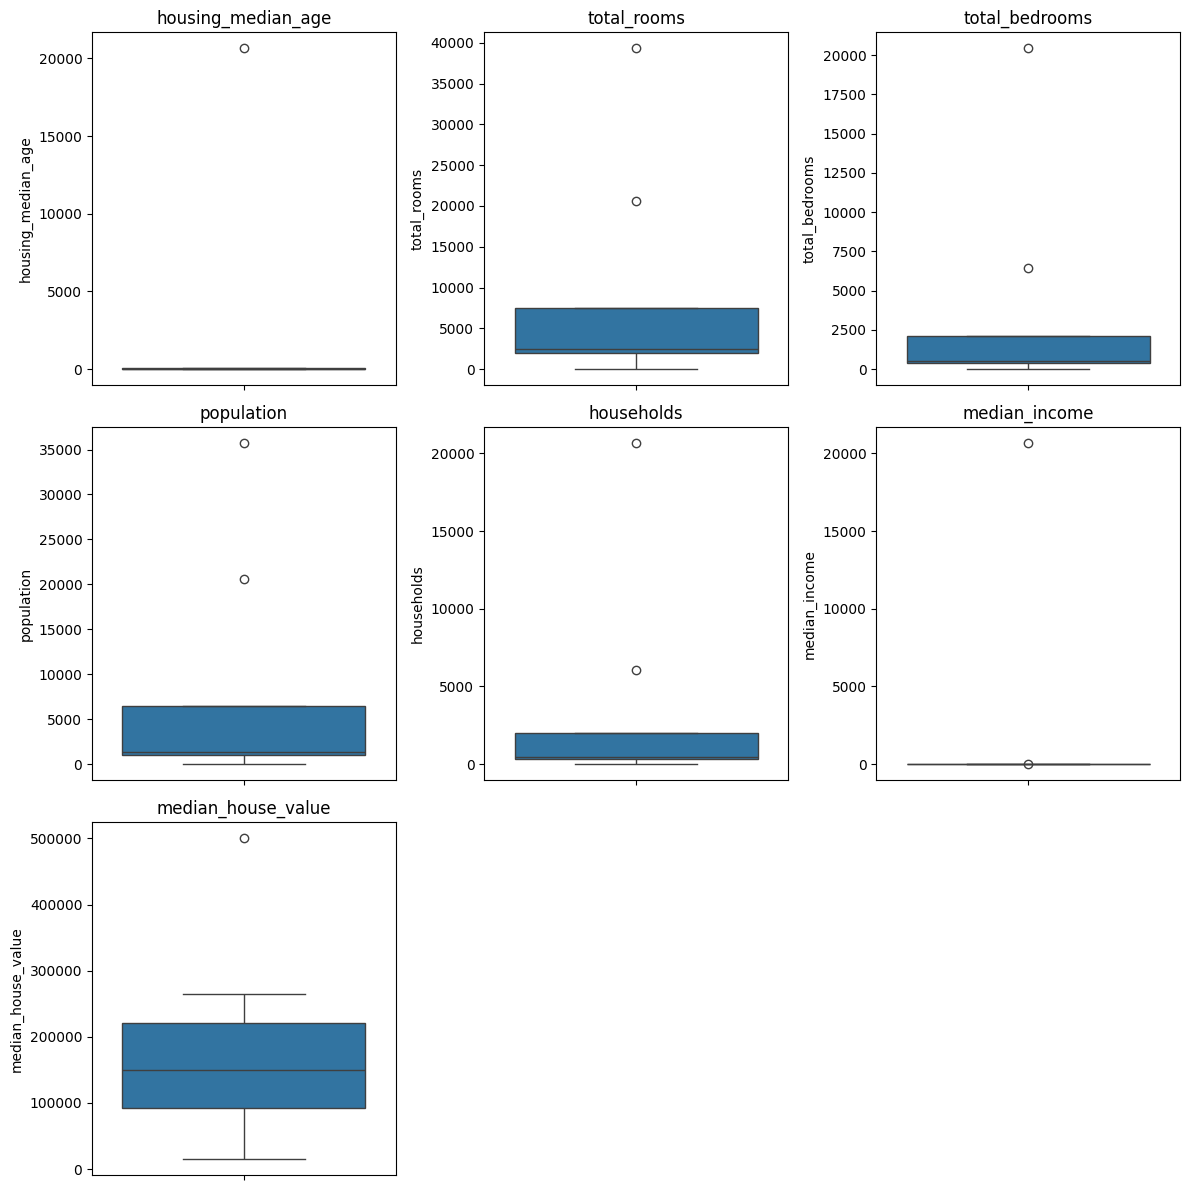

In [112]:
discrip_cols = data_descibtion.drop(columns=['longitude','latitude']).columns
n_cols = 3
n_rows = (len(discrip_cols)+n_cols) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4*n_rows))
axes = axes.flatten()
for i, col in enumerate(discrip_cols):
    sns.boxplot(y=data_descibtion[col], ax=axes[i])
    axes[i].set_title(col)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

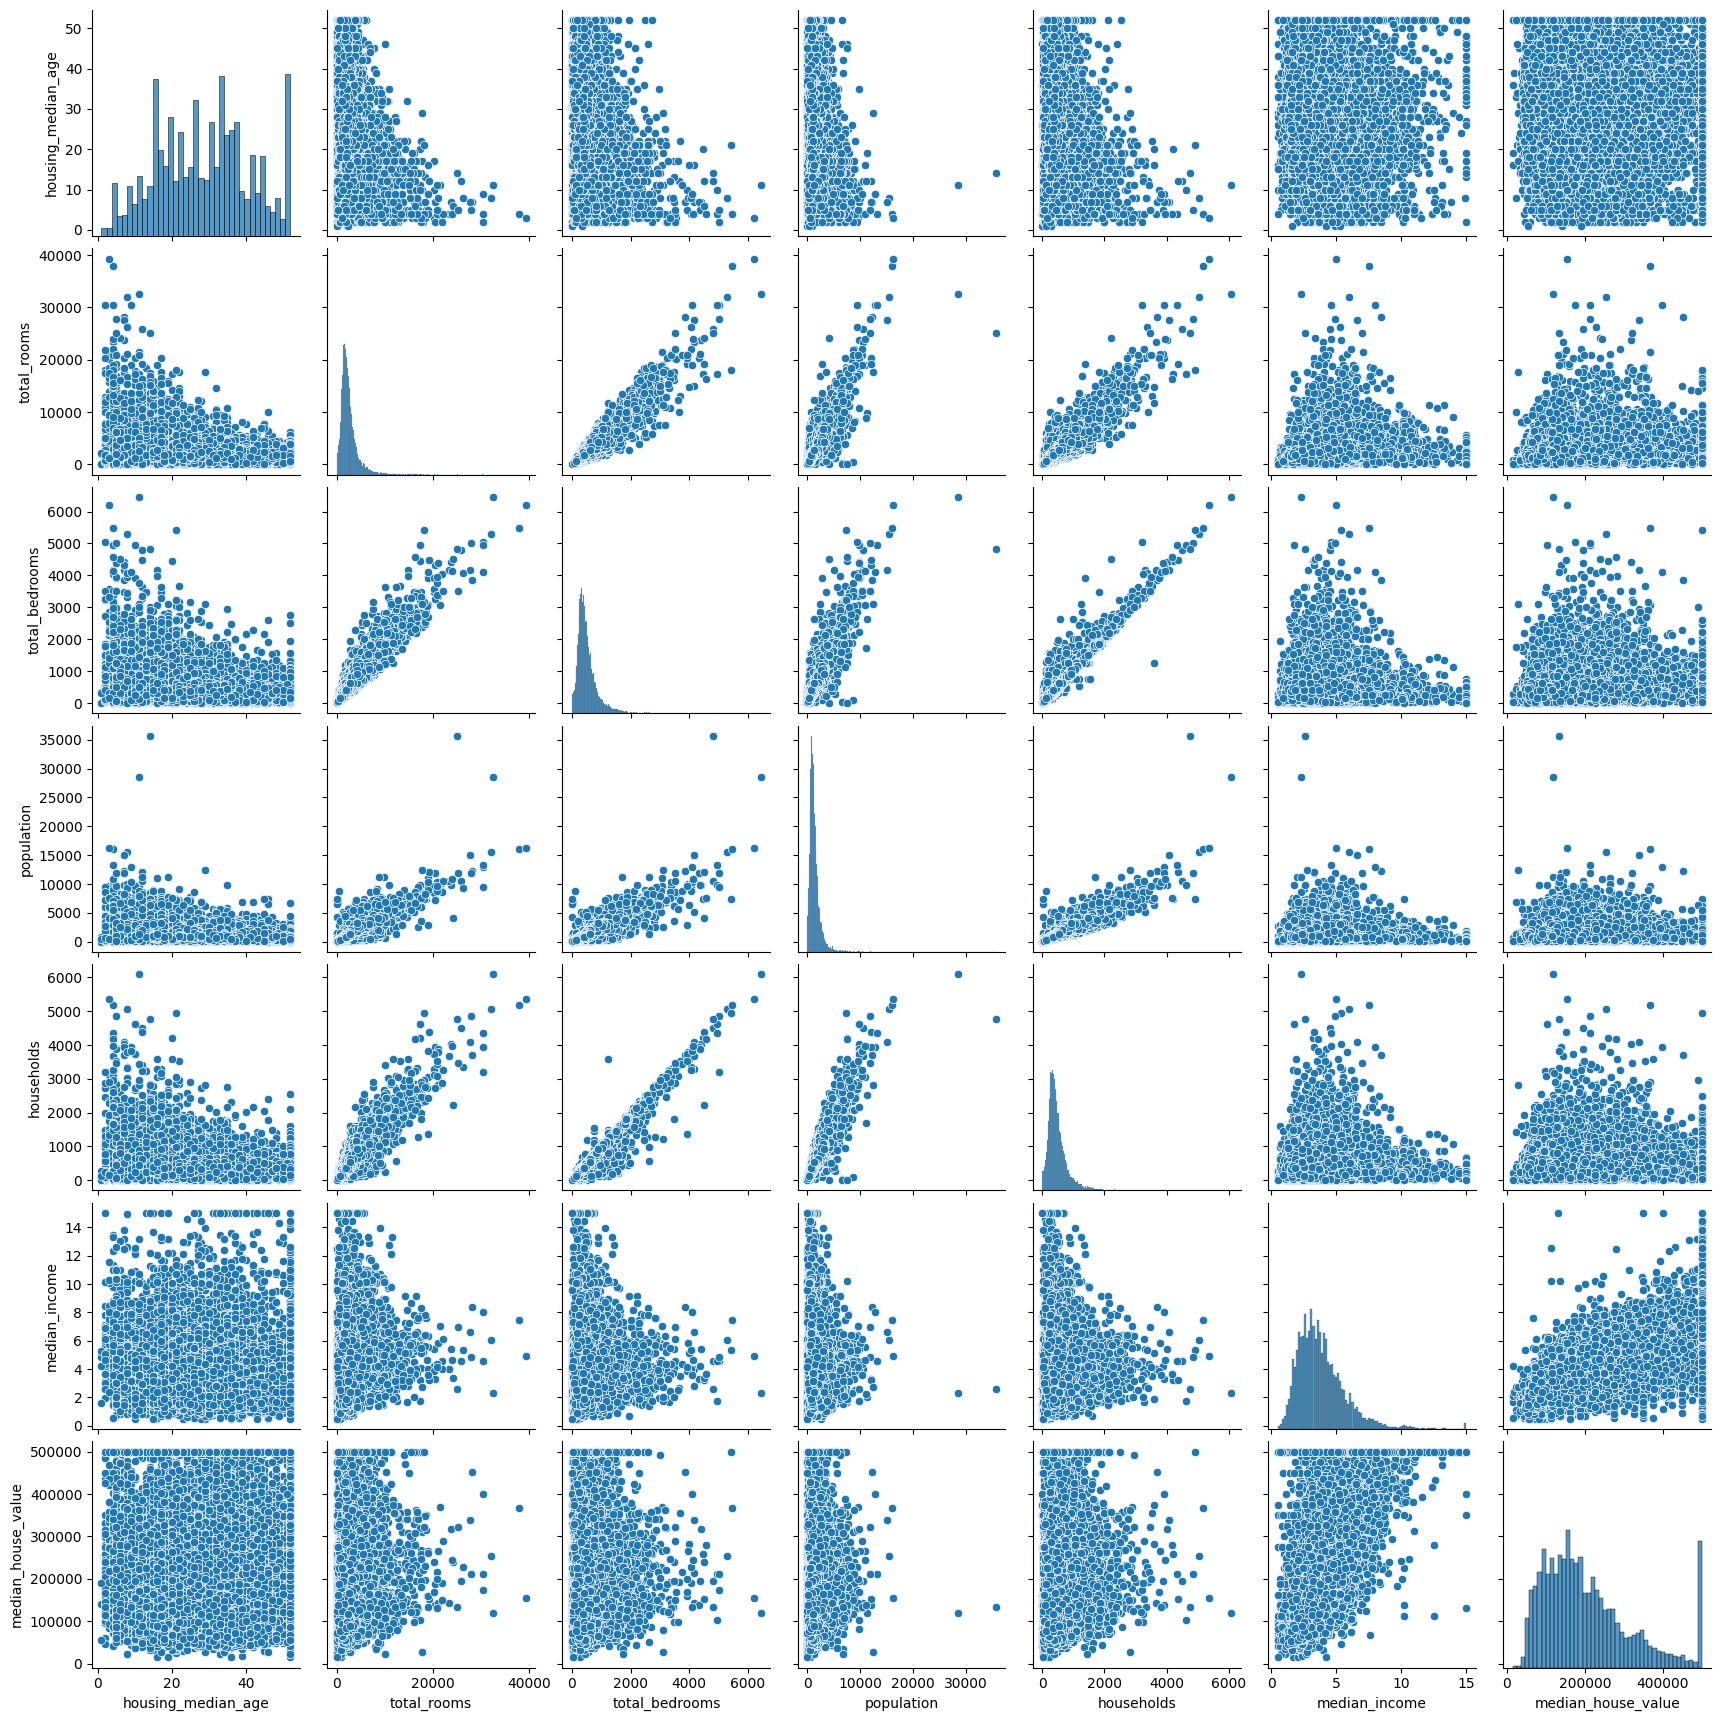

In [113]:
sns.pairplot(df.drop(columns=['longitude','latitude','rooms_bin']))
plt.show()

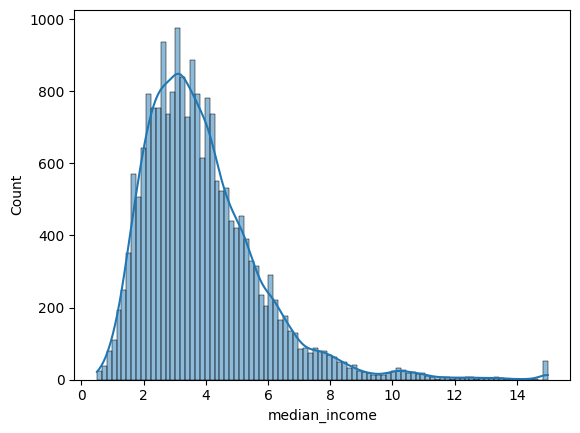

In [114]:
sns.histplot(df['median_income'],kde=True)
plt.show()

In [115]:
bins = [0, 3, 6, 9, 12, 14,18]
labels = [1, 2, 3, 4, 5,6]

df["income"] = pd.cut(df["median_income"], bins=bins, labels=labels)

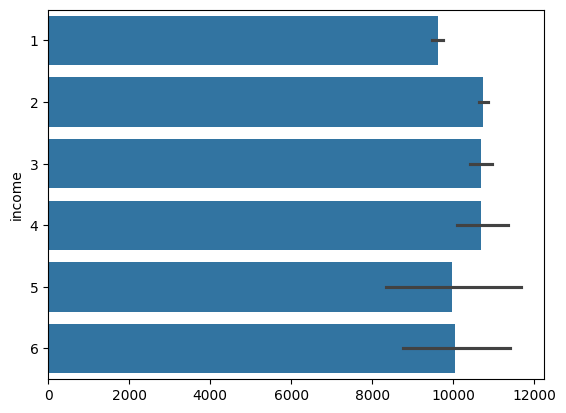

In [116]:
sns.barplot(df['income'])
plt.show()

In [117]:
Q1 = df['median_house_value'].quantile(0.25)
Q3 = df['median_house_value'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['median_house_value'] > upper)]

print(outliers.shape[0])

1071


In [118]:
df['median_house_value'].skew()

np.float64(0.9777632739098342)

In [119]:
df['median_house_value'] = np.log1p(df['median_house_value'])

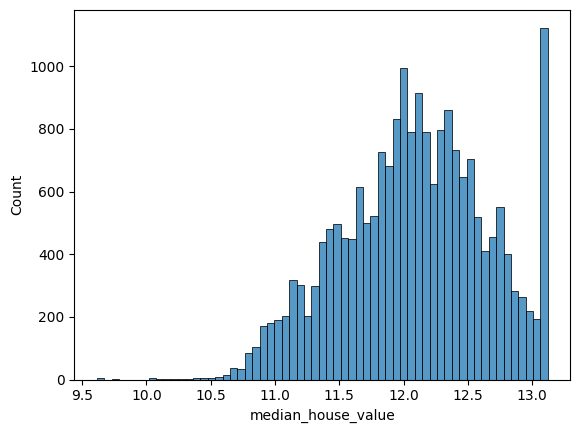

In [120]:
sns.histplot(df['median_house_value'])
plt.show()

In [121]:
ocean_prox_data = df['ocean_proximity'].value_counts()

In [122]:
prox_df = pd.DataFrame(ocean_prox_data).reset_index()

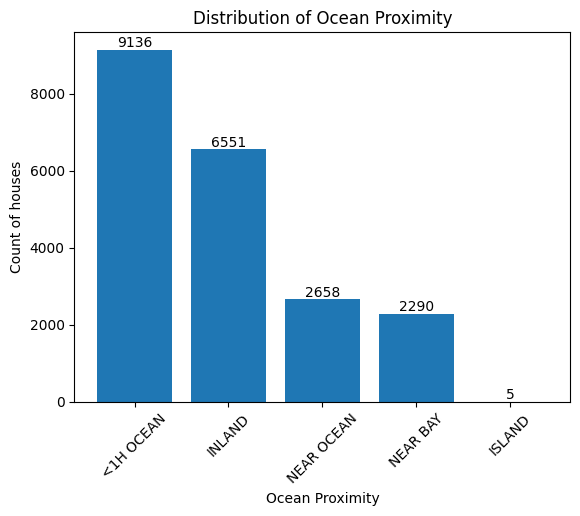

In [123]:
fig, ax = plt.subplots()

bars = ax.bar(prox_df['ocean_proximity'], prox_df['count'])
ax.set_xlabel("Ocean Proximity")
ax.set_ylabel("Count of houses")
ax.set_title("Distribution of Ocean Proximity")
plt.xticks(rotation=45)
ax.bar_label(bars)
plt.show()

In [124]:
df["housing_median_age"].skew()

np.float64(0.06033063759913685)

<Axes: >

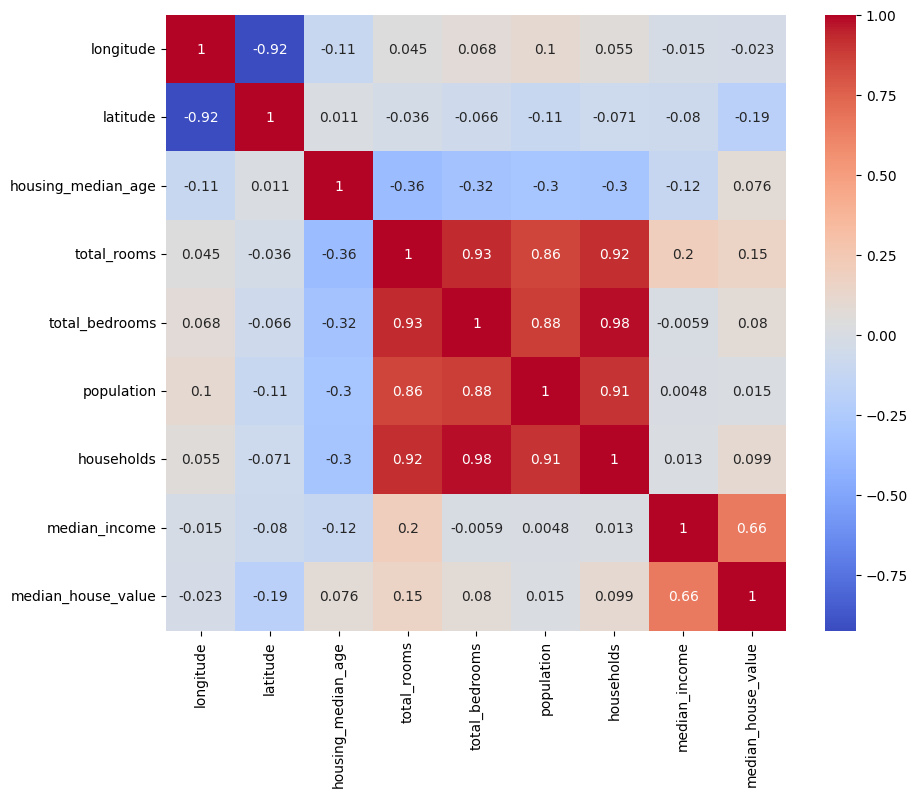

In [125]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")

<Axes: xlabel='ocean_proximity', ylabel='median_house_value'>

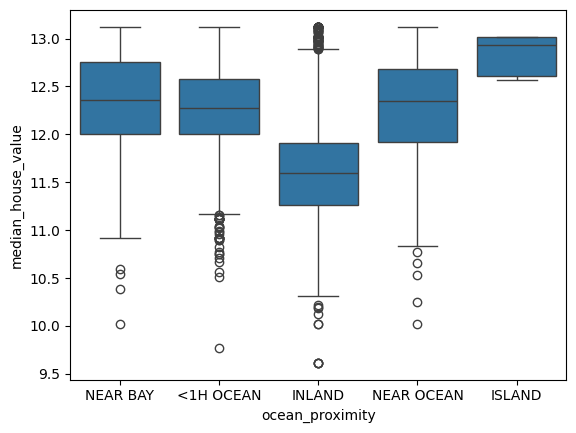

In [126]:
sns.boxplot(x="ocean_proximity", y="median_house_value", data=df)

<Axes: xlabel='longitude', ylabel='latitude'>

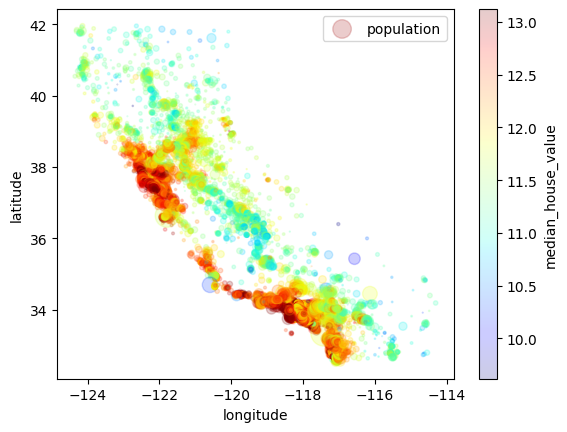

In [127]:
df.plot(
    kind="scatter",
    x="longitude",
    y="latitude",
    alpha=0.2,
    s=df["population"]/100,
    label="population",
    c="median_house_value",
    cmap="jet",
    colorbar=True
)

In [128]:
df.to_csv("data_cleaned.csv")